<a href="https://colab.research.google.com/github/zorGizem/Erken-Evre-Alzhemir-Tespiti/blob/main/notebooks/01_CN_Zip_Extracting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

# 1. Drive'ı Mount Et (Bağla)
drive.mount('/content/drive')

# 2. AYARLAR - Burayı kendi klasör isimlerine göre düzenle
# Ziplerin olduğu klasör (Örn: EMCI_Zipler klasörü)
zip_kaynak_yolu = '/content/drive/MyDrive/Gizem Zor/YAZILIM TASARIMI/Bitirme/Dataset/dataset_zip/CN_Zip'

# Dosyaların birleşeceği ana klasör
hedef_klasor = '/content/drive/MyDrive/Gizem Zor/YAZILIM TASARIMI/Bitirme/Dataset/dataset/CN'

# 3. İşlemi Başlat
if not os.path.exists(hedef_klasor):
    os.makedirs(hedef_klasor)
    print(f"Hedef klasör oluşturuldu: {hedef_klasor}")

print("Zipleri birleştirme ve açma işlemi başlıyor...\n")

# Klasördeki tüm dosyaları tara
for dosya in os.listdir(zip_kaynak_yolu):
    if dosya.endswith(".zip"):
        tam_yol = os.path.join(zip_kaynak_yolu, dosya)
        print(f"Açılıyor: {dosya}")

        # -q: Sessiz mod (ekranı binlerce satırla doldurmaz)
        # -o: Üzerine yaz (dosya çakışmalarını otomatik çözer)
        # -d: Hedef dizin
        os.system(f'unzip -q -o "{tam_yol}" -d "{hedef_klasor}"')

print("\n--- İŞLEM TAMAMLANDI ---")
print(f"Tüm dosyalar şu klasörde birleşti: {hedef_klasor}")

Mounted at /content/drive
Zipleri birleştirme ve açma işlemi başlıyor...

Açılıyor: cn (1).zip
Açılıyor: cn1.zip
Açılıyor: cn2.zip

--- İŞLEM TAMAMLANDI ---
Tüm dosyalar şu klasörde birleşti: /content/drive/MyDrive/Gizem Zor/YAZILIM TASARIMI/Bitirme/Dataset/dataset/CN


In [ ]:
!pip install pydicom matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.0 MB/s eta 0:00:00


Görüntülenen Dosya Yolu: /content/drive/MyDrive/Gizem Zor/YAZILIM TASARIMI/Bitirme/Dataset/dataset/CN/ADNI/135_S_4598/MPRAGE/2012-03-20_13_21_59.0/I291138/ADNI_135_S_4598_MR_MPRAGE_br_raw_20120320143742242_176_S144209_I291138.dcm


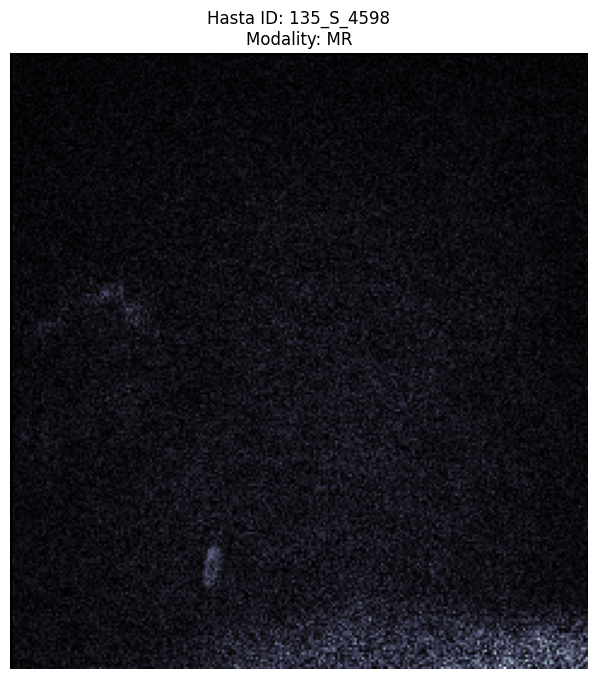

In [ ]:
import pydicom
import matplotlib.pyplot as plt
import os
import random

# 1. Veri yolunu tanımla (Ekran görüntündeki yola göre güncellendi)
# Unzip ettiğin klasörün tam yolu
ana_yol = '/content/drive/MyDrive/Gizem Zor/YAZILIM TASARIMI/Bitirme/Dataset/dataset/CN/ADNI'

def rastgele_mri_goster(yol):
    # Klasördeki tüm .dcm dosyalarını tara
    tum_dosyalar = []
    for root, dirs, files in os.walk(yol):
        for file in files:
            if file.endswith(".dcm"):
                tum_dosyalar.append(os.path.join(root, file))

    if not tum_dosyalar:
        print(f"Hata: {yol} klasöründe .dcm dosyası bulunamadı!")
        return

    # Rastgele bir dosya seç
    secilen_dosya = random.choice(tum_dosyalar)
    print(f"Görüntülenen Dosya Yolu: {secilen_dosya}")

    # DICOM dosyasını oku [cite: 2026-02-21]
    ds = pydicom.dcmread(secilen_dosya)

    # Ekrana bas [cite: 2026-02-21]
    plt.figure(figsize=(8, 8))
    # MRI verisi ds.pixel_array içindedir. cmap='bone' tıbbi görüntüler için standarttır.
    plt.imshow(ds.pixel_array, cmap=plt.cm.bone)
    plt.title(f"Hasta ID: {ds.PatientID}\nModality: {ds.Modality}")
    plt.axis('off')
    plt.show()

# 2. Fonksiyonu çalıştır
rastgele_mri_goster(ana_yol)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# İstatistiklerini görmek istediğin klasör yolu (Örn: CN grubu için)
ana_yol = '/content/drive/MyDrive/Gizem Zor/YAZILIM TASARIMI/Bitirme/Dataset/dataset/CN/ADNI'

def veri_setini_ozetle(yol):
    if not os.path.exists(yol):
        print(f"HATA: {yol} adresi bulunamadı!")
        return

    # 1. Hasta Sayısını Bul (ADNI klasörünün hemen altındaki klasörler)
    hastalar = [d for d in os.listdir(yol) if os.path.isdir(os.path.join(yol, d))]
    toplam_hasta = len(hastalar)

    # 2. Tüm Görüntüleri ve Hasta Başına Dağılımı Bul
    toplam_goruntu = 0
    hasta_detaylari = {}

    print(f"--- {os.path.basename(os.path.dirname(yol))} GRUBU ANALİZİ ---")

    for hasta in hastalar:
        hasta_yolu = os.path.join(yol, hasta)
        sayac = 0
        # Hastanın altındaki tüm klasörleri tara ve .dcm dosyalarını say
        for root, dirs, files in os.walk(hasta_yolu):
            for file in files:
                if file.endswith(".dcm"):
                    sayac += 1

        toplam_goruntu += sayac
        hasta_detaylari[hasta] = sayac

    # 3. Sonuçları Ekrana Yazdır
    print(f"Toplam Hasta Sayısı: {toplam_hasta}")
    print(f"Toplam Görüntü (.dcm) Sayısı: {toplam_goruntu}")
    print(f"Hasta Başına Ortalama Görüntü: {toplam_goruntu // toplam_hasta if toplam_hasta > 0 else 0}")
    print("-" * 30)

    # İlk 5 hastanın detayını örnek olarak göster
    print("Örnek Hasta Detayları (İlk 5):")
    for i, (h_id, miktar) in enumerate(list(hasta_detaylari.items())[:5]):
        print(f"  > Hasta ID: {h_id} | Görüntü Sayısı: {miktar}")

# Fonksiyonu çalıştır
veri_setini_ozetle(ana_yol)

--- CN GRUBU ANALİZİ ---
Toplam Hasta Sayısı: 128
Toplam Görüntü (.dcm) Sayısı: 27692
Hasta Başına Ortalama Görüntü: 216
------------------------------
Örnek Hasta Detayları (İlk 5):
  > Hasta ID: 011_S_0002 | Görüntü Sayısı: 160
  > Hasta ID: 099_S_0040 | Görüntü Sayısı: 320
  > Hasta ID: 067_S_0059 | Görüntü Sayısı: 320
  > Hasta ID: 114_S_0166 | Görüntü Sayısı: 160
  > Hasta ID: 082_S_0304 | Görüntü Sayısı: 160


# Task
Unzip the provided zip files from `/content/drive/MyDrive/Gizem Zor/YAZILIM TASARIMI/Bitirme/Dataset/dataset_zip/CN_Zip` into the `/content/drive/MyDrive/Gizem Zor/YAZILIM TASARIMI/Bitirme/Dataset/dataset/CN` directory, debug any issues that prevent the correct extraction of DICOM files, and then successfully display a random DICOM image from the extracted files.

## Kaynak ve Hedef Klasörlerin Mevcut Durumunu Kontrol Et

### Subtask:
Unzip işlemine başlamadan önce `zip_kaynak_yolu` ve `hedef_klasor` değişkenlerinin gerçekten beklendiği yollara işaret ettiğinden emin olmak için bu yolların içeriklerini listele. Ayrıca `hedef_klasor`'ün boş olup olmadığını kontrol et. Bu adım, yolların doğru tanımlandığından ve erişilebilir olduğundan emin olmamızı sağlar.


**Reasoning**:
To verify the paths and contents before proceeding, I will list the contents of `zip_kaynak_yolu` and `hedef_klasor` and check if `hedef_klasor` is empty, as instructed.

